**You are the average of the five people you spend the most time with.    - Jim Rohn**

The Quote: Suggests that an individual is shaped by the influences of the people closest to them.

k-NN Algorithm: Determines the class or value of a data point based on the characteristics of its closest neighbors in the feature space.

In both cases, proximity to a group influences the outcome:

In the quote, proximity is in terms of relationships or time spent.

In k-NN, proximity is in terms of Euclidean distance (or another metric) in a feature space.

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix

In [25]:
# Load Data
df_original = pd.read_csv('Children Recode_final.csv')

# Drop unnecessary columns
df = df_original.drop(['Underweight', 'Wasting'], axis=1)

# Feature and Target selection
X = df.drop(columns=['Stunting'])
y = df['Stunting']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# KNN Model
knn = KNeighborsClassifier(n_neighbors=19)
knn.fit(X_train, y_train)

# Predictions & Accuracy
predictions = knn.predict(X_test)
accuracy = knn.score(X_test, y_test)

accuracy


0.7745535714285714

### K-value for the best performance

In [ ]:
# Manual method
k_range = range(1, 31)
accuracy_scores = []

# Peform cross-validation for each k
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv = 5, scoring = 'accuracy') # 5 fold cross-validation
    accuracy_scores.append(scores.mean())

best_k = k_range[np.argmax(accuracy_scores)]
print(f"Best k value: {best_k}")

Best k value: 27


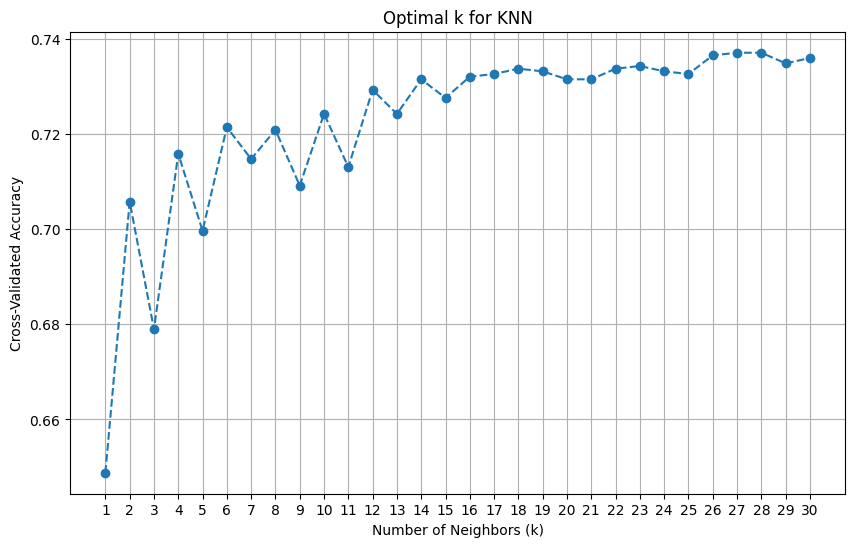

Best k: 27, Best Accuracy: 0.7370


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier

# Load Data
df_original = pd.read_csv('Children Recode_final.csv')  # Ensure the file is in the correct path

# Drop unnecessary columns
df = df_original.drop(['Underweight', 'Wasting'], axis=1)

# Feature and Target selection
X = df.drop(columns=['Stunting'])
y = df['Stunting']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Find the best k using cross-validation
k_values = range(1, 31)  # Trying k from 1 to 30
cv_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')  # 10-fold cross-validation
    cv_scores.append(scores.mean())

# Find the best k
best_k = k_values[np.argmax(cv_scores)]
best_accuracy = max(cv_scores)

# Plot k vs accuracy
plt.figure(figsize=(10, 6))
plt.plot(k_values, cv_scores, marker='o', linestyle='dashed')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Cross-Validated Accuracy')
plt.title('Optimal k for KNN')
plt.xticks(k_values)
plt.grid(True)
plt.show()

print(f'Best k: {best_k}, Best Accuracy: {best_accuracy:.4f}')


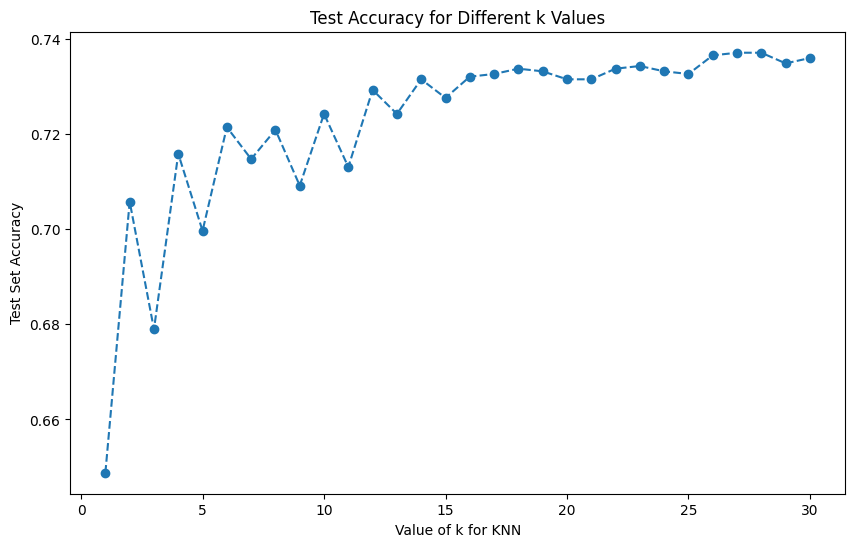

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(k_range, accuracy_scores, marker='o', linestyle='--')
plt.xlabel('Value of k for KNN')
plt.ylabel('Test Set Accuracy')
plt.title('Test Accuracy for Different k Values')
plt.show()

In [14]:
# Using GridSearchCV
knn = KNeighborsClassifier()

# Define the grid of k values
param_grid = {'n_neighbors': range(1, 31)}

# Perform grid search with cross-validation
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Best k value
print("Best k:", grid_search.best_params_['n_neighbors'])
print("Best accuracy:", grid_search.best_score_)


Best k: 27
Best accuracy: 0.737017786838051


Even thoufh best k value received is 11, the default k = 5 works better for accuracy.

In [9]:
# Synthetic Minority Oversampling Technique (SMOTE)

y.value_counts()

Stunting
0    1660
1     579
Name: count, dtype: int64

1. why do the k=11 has less accuracy
2. 